# Step 2 — Exploratory Data Analysis and Feature Engineering

This notebook analyzes the cleaned data, studies the factors affecting delivery time, and creates new useful features.

In [48]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from feature_engineering import add_features

In [49]:
# Define project paths
project_root = Path.cwd().parent

cleaned_data_path = (
    project_root / "data" / "processed" / "delivery_clean.csv"
)

print("project root:", project_root)
print("Dataset path:", cleaned_data_path)

project root: /home/bsar/Desktop/delivery-eta
Dataset path: /home/bsar/Desktop/delivery-eta/data/processed/delivery_clean.csv


In [50]:
# load the cleaned dataset
import pandas as pd

cleaned_dataframe = pd.read_csv(cleaned_data_path)

print("Dataset shape:", cleaned_dataframe.shape)
display(cleaned_dataframe.head())

Dataset shape: (40353, 11)


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_vehicle,City,Time_taken(min)
0,22.745049,75.892471,22.765049,75.912471,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,24.0
1,12.913041,77.683237,13.043041,77.813237,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,33.0
2,12.914264,77.678400,12.924264,77.688400,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,26.0
3,11.003669,76.976494,11.053669,77.026494,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,21.0
4,12.972793,80.249982,13.012793,80.289982,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,30.0


In [51]:
# create the new feature

featured_dataframe = add_features(
    cleaned_dataframe
)

print("Before ferature engineering:", cleaned_dataframe.shape)
print("Before ferature engineering:", cleaned_dataframe.shape)


display(featured_dataframe.head())

Before ferature engineering: (40353, 11)
Before ferature engineering: (40353, 11)


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_vehicle,City,Time_taken(min),distance_km,order_hour,preparation_time_minutes
0,22.745049,75.892471,22.765049,75.912471,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,24.0,3.025149,11,15.0
1,12.913041,77.683237,13.043041,77.813237,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,33.0,20.183530,19,5.0
2,12.914264,77.678400,12.924264,77.688400,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,26.0,1.552758,8,15.0
3,11.003669,76.976494,11.053669,77.026494,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,21.0,7.790401,18,10.0
4,12.972793,80.249982,13.012793,80.289982,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,30.0,6.210138,13,15.0


In [52]:
# check its structure 
cleaned_dataframe.info()

#check missing values
missing_report = pd.DataFrame({
    "missing_count": cleaned_dataframe.isna().sum(),
    "missing_percentage" : (
        cleaned_dataframe.isna().mean() * 100
    ).round(2)
})

display(
    missing_report.sort_values(
        by="missing_count",
        ascending=False
    )
)

<class 'pandas.DataFrame'>
RangeIndex: 40353 entries, 0 to 40352
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Restaurant_latitude          40353 non-null  float64
 1   Restaurant_longitude         40353 non-null  float64
 2   Delivery_location_latitude   40353 non-null  float64
 3   Delivery_location_longitude  40353 non-null  float64
 4   Time_Orderd                  40353 non-null  str    
 5   Time_Order_picked            40353 non-null  str    
 6   Weatherconditions            40353 non-null  str    
 7   Road_traffic_density         40353 non-null  str    
 8   Type_of_vehicle              40353 non-null  str    
 9   City                         40353 non-null  str    
 10  Time_taken(min)              40353 non-null  float64
dtypes: float64(5), str(6)
memory usage: 5.2 MB


,missing_count,missing_percentage
Restaurant_latitude,0,0.0
Restaurant_longitude,0,0.0
Delivery_location_latitude,0,0.0
Delivery_location_longitude,0,0.0
Time_Orderd,0,0.0
Time_Order_picked,0,0.0
Weatherconditions,0,0.0
Road_traffic_density,0,0.0
Type_of_vehicle,0,0.0
City,0,0.0


In [53]:
# Display newly created features
new_features = sorted(
    set(featured_dataframe.columns)
    - set(cleaned_dataframe.columns)
)

print("New features:")

for feature in new_features:
    print(f"- {feature}")

New features:
- distance_km
- order_hour
- preparation_time_minutes


In [54]:
# Numerical statistics

numerical_columns = (
    featured_dataframe
    .select_dtypes(include="number")
    .columns
)

numerical_statistics = (
    featured_dataframe[numerical_columns]
    .agg(["mean", "median", "std", "min", "max"])
    .T
)

display(numerical_statistics.round(2))


,mean,median,std,min,max
Restaurant_latitude,18.91,19.07,5.47,9.96,30.91
Restaurant_longitude,76.92,76.62,3.50,72.77,88.43
Delivery_location_latitude,18.98,19.12,5.47,9.97,31.05
Delivery_location_longitude,76.98,76.66,3.50,72.78,88.56
Time_taken(min),26.31,26.00,9.37,10.00,54.00
distance_km,9.72,9.19,5.60,1.47,20.97
order_hour,17.42,19.00,4.82,0.00,23.00
preparation_time_minutes,9.98,10.00,4.09,5.00,15.00


In [55]:
categorical_columns = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_vehicle",
    "City",
]

for column in categorical_columns:
    print(f"\n -- {column} ---")

    display(
        featured_dataframe[column]
        .value_counts()
        .to_frame("frequency")
    )


 -- Weatherconditions ---


,frequency
Weatherconditions,
Fog,6845
Stormy,6806
Cloudy,6747
Sandstorms,6717
Windy,6675
Sunny,6563



 -- Road_traffic_density ---


,frequency
Road_traffic_density,
Low,13816
Jam,12726
Medium,9836
High,3975



 -- Type_of_vehicle ---


,frequency
Type_of_vehicle,
motorcycle,23660
scooter,13489
electric_scooter,3204



 -- City ---


,frequency
City,
Metropolitian,31279
Urban,8933
Semi-Urban,141


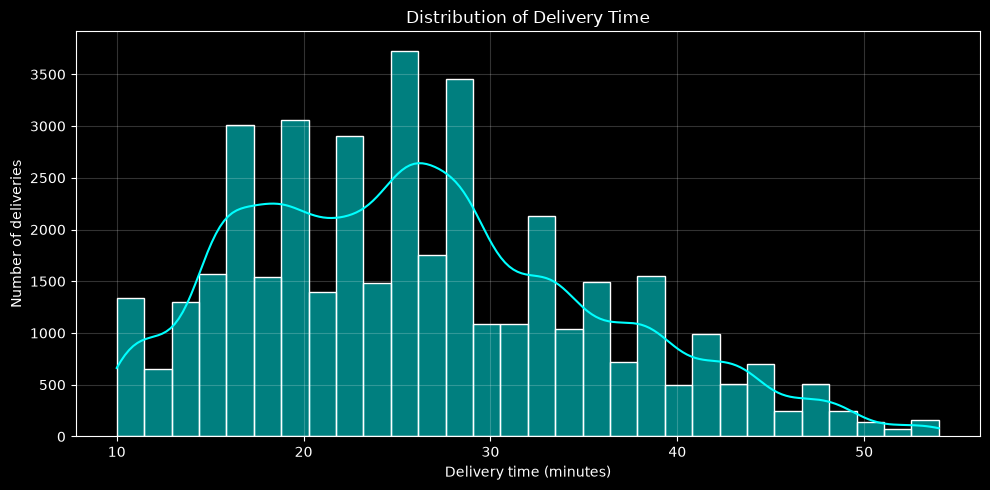

In [56]:
from matplotlib import pyplot as plt
import seaborn as sns

# Set overall dark background theme
plt.style.use("dark_background")

plt.figure(figsize=(10, 5))

sns.histplot(
    data=featured_dataframe,
    x="Time_taken(min)",
    bins=30,
    kde=True,
    color="cyan"  # Bright colors stand out better on dark backgrounds
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery time (minutes)")
plt.ylabel("Number of deliveries")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [57]:
# Target statistics

target_statistics = (
    featured_dataframe["Time_taken(min)"]
    .agg(["mean", "median", "std", "min", "max"])
)

display(target_statistics.round(2))

mean      26.31
median    26.00
std        9.37
min       10.00
max       54.00
Name: Time_taken(min), dtype: float64

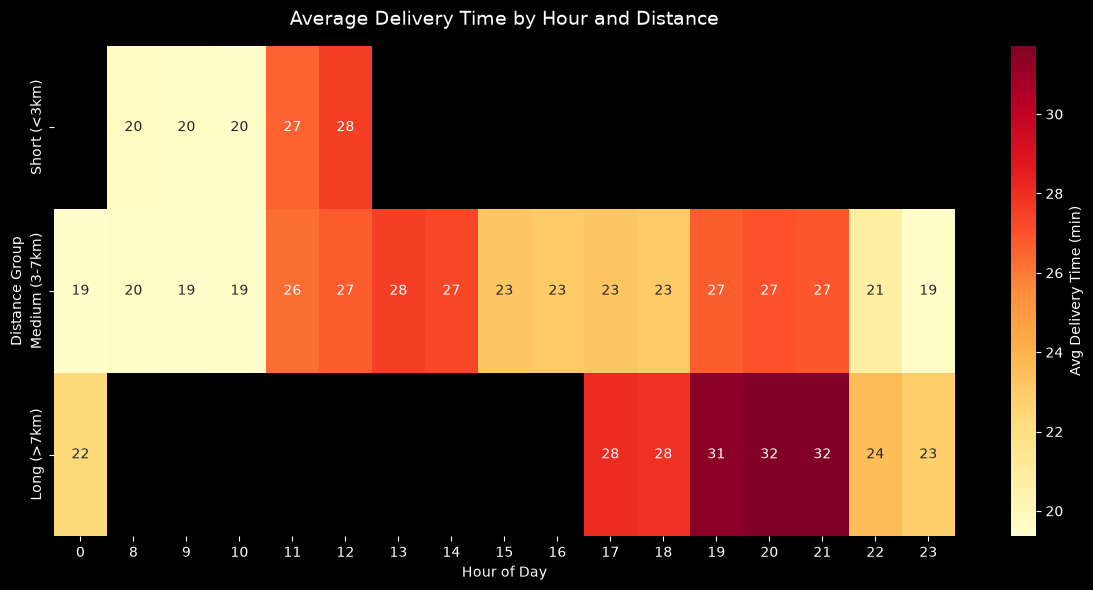

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
plt.figure(figsize=(12, 6))

# 1. Create simple distance categories
featured_dataframe['distance_group'] = pd.cut(
    featured_dataframe['distance_km'],
    bins=[0, 3, 7, 50],
    labels=['Short (<3km)', 'Medium (3-7km)', 'Long (>7km)']
)

# 2. Group by hour and distance category to get average delivery time
heatmap_data = featured_dataframe.groupby(
    ['distance_group', 'order_hour']
)['Time_taken(min)'].mean().unstack()

# 3. Plot as a single heatmap
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",  # Yellow to Red color scale (Red = Slower)
    annot=True,     # Show exact delivery time numbers in cells
    fmt=".0f",      # Round to whole numbers
    cbar_kws={'label': 'Avg Delivery Time (min)'}
)

plt.title("Average Delivery Time by Hour and Distance", fontsize=14, pad=15)
plt.xlabel("Hour of Day")
plt.ylabel("Distance Group")
plt.tight_layout()
plt.show()

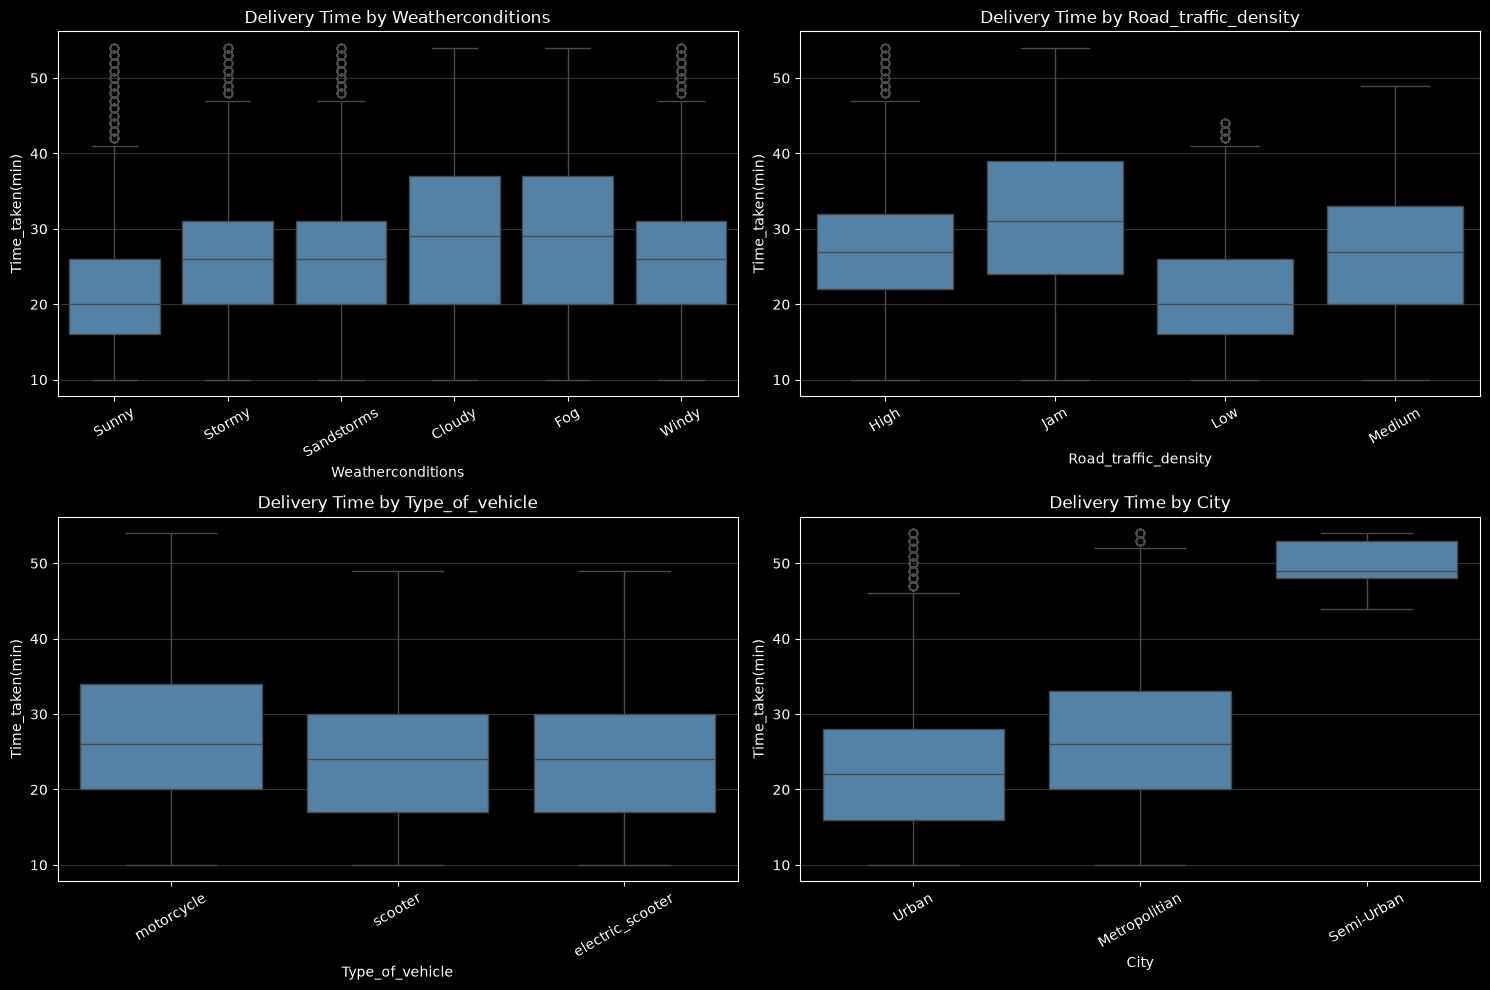

In [59]:
# Target and categorical columns
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    facecolor="black"
)

for column, axis in zip(
    categorical_columns,
    axes.flat
):
    sns.boxplot(
        data=featured_dataframe,
        x=column,
        y="Time_taken(min)",
        color="steelblue",
        ax=axis
    )

    axis.set_title(
        f"Delivery Time by {column}"
    )
    axis.tick_params(
        axis="x",
        rotation=30
    )
    axis.set_facecolor("black")
    axis.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

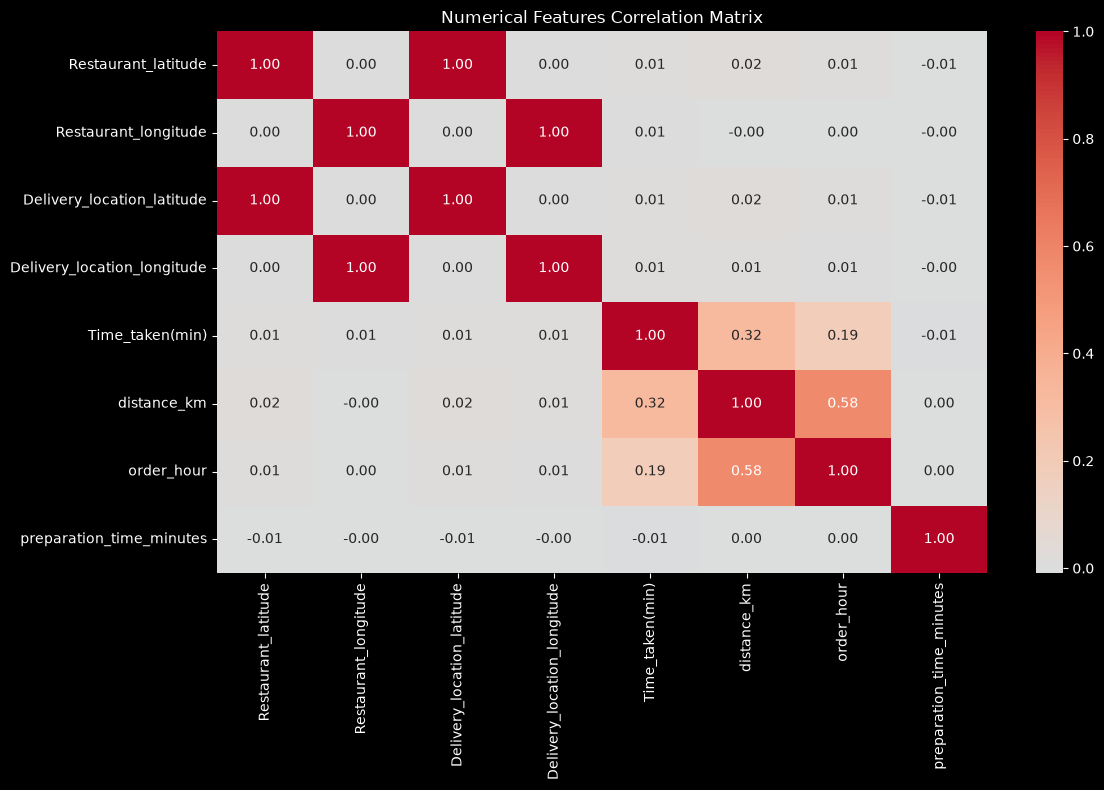

In [60]:
# Correlation matrix
correlation_matrix = (
    featured_dataframe
    .select_dtypes(include="number")
    .corr()
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Features Correlation Matrix")
plt.tight_layout()
plt.show()

In [61]:
# Variables most correlated with the target

target_correlations = (
    correlation_matrix["Time_taken(min)"]
    .drop("Time_taken(min)")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    target_correlations.to_frame(
        "correlation_with_delivery_time"
    )
)

,correlation_with_delivery_time
distance_km,0.321259
order_hour,0.185275
Delivery_location_latitude,0.014493
Delivery_location_longitude,0.012501
Restaurant_latitude,0.012341
preparation_time_minutes,-0.009563
Restaurant_longitude,0.009132


In [62]:
# Validate new features
feature_validation = featured_dataframe[
    [
        "distance_km",
        "order_hour",
        "preparation_time_minutes",
    ]
].describe().T

display(feature_validation.round(2))

,count,mean,std,min,25%,50%,75%,max
distance_km,40353.0,9.72,5.60,1.47,4.66,9.19,13.63,20.97
order_hour,40353.0,17.42,4.82,0.00,15.00,19.00,21.00,23.00
preparation_time_minutes,40353.0,9.98,4.09,5.00,5.00,10.00,15.00,15.00


In [63]:
columns_to_drop = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Time_Orderd",
    "Time_Order_picked",
]

model_dataframe = featured_dataframe.drop(
    columns= columns_to_drop
)

display(model_dataframe.head())

print("Final shape:", model_dataframe.shape)

,Weatherconditions,Road_traffic_density,Type_of_vehicle,City,Time_taken(min),distance_km,order_hour,preparation_time_minutes,distance_group
0,Sunny,High,motorcycle,Urban,24.0,3.025149,11,15.0,Medium (3-7km)
1,Stormy,Jam,scooter,Metropolitian,33.0,20.183530,19,5.0,Long (>7km)
2,Sandstorms,Low,motorcycle,Urban,26.0,1.552758,8,15.0,Short (<3km)
3,Sunny,Medium,motorcycle,Metropolitian,21.0,7.790401,18,10.0,Long (>7km)
4,Cloudy,High,scooter,Metropolitian,30.0,6.210138,13,15.0,Medium (3-7km)


Final shape: (40353, 9)


In [65]:
# Save the featured dataset

featured_data_path = (
    project_root
    / "data"
    / "processed"
    / "food_delivery_featured.csv"
)

model_dataframe.to_csv(
    featured_data_path,
    index=False
)

print("Dataset saved to:", featured_data_path)

Dataset saved to: /home/bsar/Desktop/delivery-eta/data/processed/food_delivery_featured.csv
